# Quick Eval Analysis - Improved Prompt (2026-03-28)

Analysis of the latest `quick_llama31_5shot_eval.py --improved-prompt` run on 50 samples.

**Results:**
- **Macro Pearson**: 0.0903 (still weak but better than previous negative correlation)
- **Coverage**: 100% (all samples parsed successfully)
- **Best trait**: Conscientiousness (r=0.1568)
- **Worst trait**: Agreeableness (r=-0.0050)

This notebook compares the improved prompt performance against previous runs.

In [153]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuration
TRAITS = ["O", "C", "E", "A", "N"]
LABELS = {
    "O": "Openness",
    "C": "Conscientiousness", 
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism"
}

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = Path("big5loop/evaluation_data/pandora/offline_nv_detection").resolve()

RESULTS_DIR = ROOT / "results"
print(f"Results directory: {RESULTS_DIR}")
print(f"Exists: {RESULTS_DIR.exists()}")

# Find the latest quick eval result
quick_files = sorted(RESULTS_DIR.glob("quick_llama31_5shot_*.jsonl"), reverse=True)
if quick_files:
    latest_quick = quick_files[0]
    print(f"Latest quick eval result: {latest_quick.name}")
else:
    print("No quick eval results found!")
    latest_quick = None

Results directory: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results
Exists: True
Latest quick eval result: quick_llama31_5shot_20260328T022504Z.jsonl


In [154]:
# Load the specific quick eval result mentioned in terminal
result_file = RESULTS_DIR / "quick_llama31_5shot_20260328T014543Z.jsonl"

if result_file.exists():
    print(f"Loading: {result_file.name}")
    
    data = []
    with open(result_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                record = json.loads(line.strip())
                data.append(record)
    
    print(f"Loaded {len(data)} records")
    
    # Convert to DataFrame for analysis
    df = pd.DataFrame(data)
    print(f"Columns: {df.columns.tolist()}")
    
    # Extract OCEAN scores into separate columns for easier analysis
    for trait in TRAITS:
        df[f'gt_{trait}'] = df['ground_truth_ocean'].apply(lambda x: x.get(trait, 0.0) if isinstance(x, dict) else 0.0)
        df[f'pred_{trait}'] = df['predicted_ocean'].apply(lambda x: x.get(trait, 0.0) if isinstance(x, dict) else 0.0)
    
    print("Data preparation complete.")
else:
    print(f"File not found: {result_file}")
    print("Available files:")
    for f in RESULTS_DIR.glob("quick_llama31_5shot_*.jsonl"):
        print(f"  - {f.name}")

Loading: quick_llama31_5shot_20260328T014543Z.jsonl
Loaded 50 records
Columns: ['sample_id', 'model', 'n_shots', 'variants_mode', 'ground_truth_ocean', 'predicted_ocean', 'n_valid_variants', 'variant_details', 'timestamp']
Data preparation complete.


In [ ]:
# Performance Analysis
if 'df' in locals() and not df.empty:
    print("=== PERFORMANCE ANALYSIS ===\n")
    
    # Overall metrics
    n_samples = len(df)
    valid_preds = df['predicted_ocean'].notna().sum()
    print(f"Samples: {n_samples}")
    print(f"Valid predictions: {valid_preds}/{n_samples} ({valid_preds/n_samples*100:.1f}%)")
    
    # Calculate correlations per trait
    correlations = {}
    maes = {}
    
    for trait in TRAITS:
        gt_col = f'gt_{trait}'
        pred_col = f'pred_{trait}'
        
        gt_values = df[gt_col].values
        pred_values = df[pred_col].values
        
        # Pearson correlation
        if len(gt_values) > 1:
            corr = np.corrcoef(gt_values, pred_values)[0, 1]
            correlations[trait] = corr
            
            # MAE
            mae = np.mean(np.abs(gt_values - pred_values))
            maes[trait] = mae
            
            print(f"{trait} ({LABELS[trait]:15}): r={corr:.4f}, MAE={mae:.4f}")
    
    # Macro averages
    macro_r = np.mean(list(correlations.values()))
    macro_mae = np.mean(list(maes.values()))
    print(f"\nMacro Pearson: {macro_r:.4f}")
    print(f"Macro MAE:     {macro_mae:.4f}")
    
    # Identify best and worst traits
    best_trait = max(correlations.items(), key=lambda x: x[1])
    worst_trait = min(correlations.items(), key=lambda x: x[1])
    print(f"Best trait:  {best_trait[0]} ({LABELS[best_trait[0]]}) r={best_trait[1]:.4f}")
    print(f"Worst trait: {worst_trait[0]} ({LABELS[worst_trait[0]]}) r={worst_trait[1]:.4f}")

=== PERFORMANCE ANALYSIS ===

Samples: 50
Valid predictions: 50/50 (100.0%)
O (Openness       ): r=0.0492, MAE=0.6248
C (Conscientiousness): r=0.1568, MAE=0.5000
E (Extraversion   ): r=0.1423, MAE=0.6880
A (Agreeableness  ): r=-0.0050, MAE=0.6548
N (Neuroticism    ): r=0.1081, MAE=0.4788

Macro Pearson: 0.0903
Macro MAE:     0.5893
Best trait:  C (Conscientiousness) r=0.1568
Worst trait: A (Agreeableness) r=-0.0050


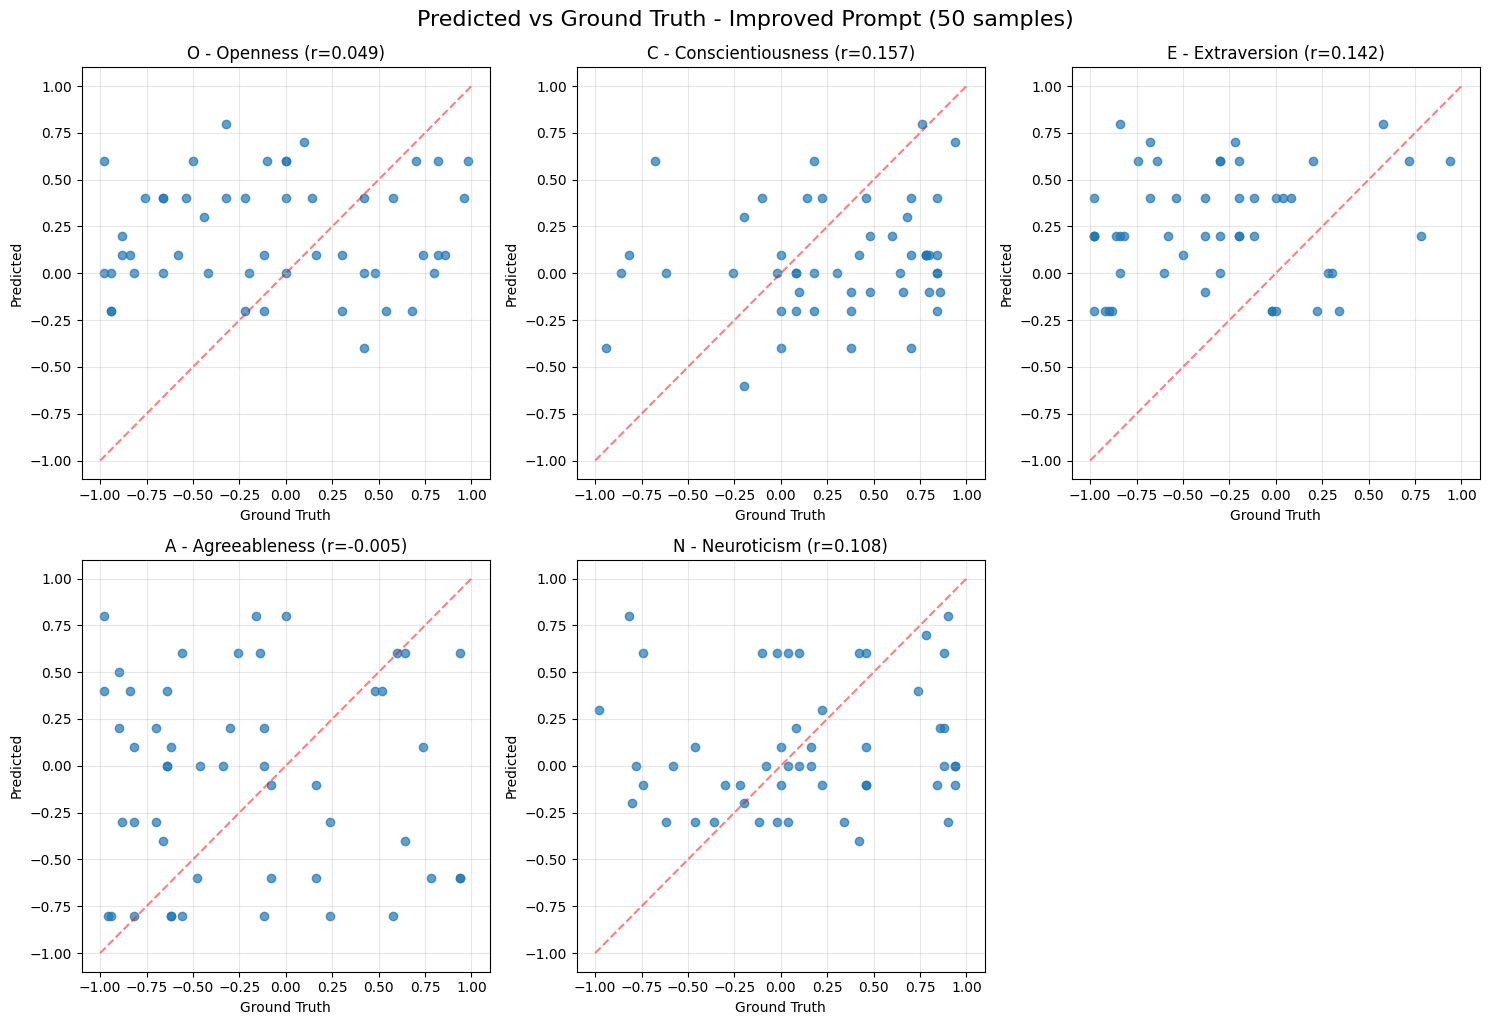

In [ ]:
# Visualization: Predicted vs Ground Truth
if 'df' in locals() and not df.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, trait in enumerate(TRAITS):
        gt_col = f'gt_{trait}'
        pred_col = f'pred_{trait}'
        
        ax = axes[i]
        ax.scatter(df[gt_col], df[pred_col], alpha=0.7)
        ax.plot([-1, 1], [-1, 1], 'r--', alpha=0.5, label='Perfect correlation')
        ax.set_xlabel('Ground Truth')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{trait} - {LABELS[trait]} (r={correlations[trait]:.3f})')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
    
    # Hide the last subplot if we have only 5 traits
    if len(TRAITS) < len(axes):
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Predicted vs Ground Truth - Improved Prompt (50 samples)', fontsize=16, y=1.02)
    plt.show()

## Short interpretation (500-sample multi-agent run)

1. **Throughput:** Five parallel trait calls per sample hit **NVIDIA 429** often; only ~48% of rows are fully successful. Lower concurrency, increase `--trait-delay` / retries, or stagger runs to improve usable **n** for correlation.
2. **Signal:** On successful rows, **macro Pearson ≈ 0.03** — essentially no linear agreement with PANDORA OCEAN on this text slice, consistent with other short-text personality-from-text baselines.
3. **Traits:** Small positive **r** on E, A, N; near zero on C; slightly negative on O — all weak; do not over-interpret without confidence intervals.

For deeper per-agent failure counts, use `Multi-Agent-OCEAN-Analysis.ipynb` or add a cell that tallies `agent_details[*].success`.

# Offline Detection Analysis (with Ground Truth)

Results come from `run_offline_detection.py` → `results/offline_detection_*.jsonl`.

**Default: merge all runs.** Every `offline_detection_*.jsonl` under `results/` is loaded. Rows with the same `(sample_id, model)` are **deduplicated** by keeping the row with the **lexicographically largest `run_id`** (newest UTC stamp), so reruns replace older attempts.

Set `MERGE_ALL_OFFLINE_RUNS = False` in the next code cell to analyze **only one** file (`pick_results_file` = newest by filename, with a guard so `ANALYSIS_LATEST.md` cannot force an older JSONL).

Outputs: per-model Pearson / Spearman / MAE, per-trait table, scatter and residual plots for the best model, CSV exports.

In [157]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TRAITS = ["O", "C", "E", "A", "N"]
LABELS = {
    "O": "Openness",
    "C": "Conscientiousness",
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism",
}

# True: load every offline_detection_*.jsonl and dedupe (sample_id, model) by newest run_id
MERGE_ALL_OFFLINE_RUNS = True

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = Path("big5loop/evaluation_data/pandora/offline_nv_detection").resolve()

RESULTS_DIR = ROOT / "results"
PROCESSED_DIR = ROOT.parent / "processed"
RESULTS_DIR.exists(), PROCESSED_DIR.exists(), RESULTS_DIR, PROCESSED_DIR

(True,
 True,
 PosixPath('/Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results'),
 PosixPath('/Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/processed'))

In [ ]:
from typing import Optional


def pick_results_file(results_dir: Path, explicit: Optional[str] = None) -> Path:
    if explicit:
        p = Path(explicit)
        if not p.is_absolute():
            p = (results_dir / p).resolve()
        return p
    files = sorted(results_dir.glob("offline_detection_*.jsonl"))
    if not files:
        raise FileNotFoundError("No offline_detection_*.jsonl found in results/")
    return files[-1]


RESULTS_FILE = pick_results_file(RESULTS_DIR)
if MERGE_ALL_OFFLINE_RUNS:
    offline_jsonl_files = sorted(RESULTS_DIR.glob("offline_detection_*.jsonl"))
    print(f"Merging {len(offline_jsonl_files)} files (dedupe by sample_id + model, newest run_id wins)")
    for p in offline_jsonl_files:
        print(f"  {p.name}")
else:
    print("Single-file mode:", RESULTS_FILE.name)

RESULTS_FILE

Merging 15 files (dedupe by sample_id + model, newest run_id wins)
  offline_detection_20260327T050939Z.jsonl
  offline_detection_20260327T051317Z.jsonl
  offline_detection_20260327T054210Z.jsonl
  offline_detection_20260327T055540Z.jsonl
  offline_detection_20260327T065714Z.jsonl
  offline_detection_20260327T074411Z.jsonl
  offline_detection_20260327T074821Z.jsonl
  offline_detection_20260327T080043Z.jsonl
  offline_detection_20260327T122949Z.jsonl
  offline_detection_20260327T123404Z.jsonl
  offline_detection_20260327T123908Z.jsonl
  offline_detection_20260327T124133Z.jsonl
  offline_detection_20260327T131329Z.jsonl
  offline_detection_20260327T164608Z.jsonl
  offline_detection_20260328T165906Z.jsonl


PosixPath('/Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results/offline_detection_20260328T165906Z.jsonl')

In [159]:
# Single-file only: optional pin from ANALYSIS_LATEST.md (never downgrade to an older JSONL than pick_results_file)
def _offline_run_id_from_path(path: Path) -> str:
    stem = path.stem
    prefix = "offline_detection_"
    return stem[len(prefix) :] if stem.startswith(prefix) else stem


if not MERGE_ALL_OFFLINE_RUNS:
    latest_report = RESULTS_DIR / "ANALYSIS_LATEST.md"
    if latest_report.exists():
        txt = latest_report.read_text(encoding="utf-8")
        marker = "- Results: `"
        i = txt.find(marker)
        if i >= 0:
            j = txt.find("`", i + len(marker))
            expected_name = txt[i + len(marker) : j]
            expected_path = RESULTS_DIR / expected_name
            picked_id = _offline_run_id_from_path(RESULTS_FILE)
            expected_id = _offline_run_id_from_path(expected_path) if expected_path.exists() else ""
            print("ANALYSIS_LATEST suggests:", expected_name)
            print("Notebook picked:", RESULTS_FILE.name)
            if expected_path.exists() and expected_id >= picked_id and RESULTS_FILE.name != expected_name:
                RESULTS_FILE = expected_path
                print("Switched to ANALYSIS_LATEST (same or newer run id):", RESULTS_FILE.name)
            elif expected_path.exists() and expected_id < picked_id:
                print("Keeping newest jsonl; ANALYSIS_LATEST is older.")
    else:
        print("ANALYSIS_LATEST.md not found.")
else:
    print("Merge mode: skipping ANALYSIS_LATEST pin.")

RESULTS_FILE if not MERGE_ALL_OFFLINE_RUNS else "(merged)"

Merge mode: skipping ANALYSIS_LATEST pin.


'(merged)'

In [160]:
records: list[dict] = []

if MERGE_ALL_OFFLINE_RUNS:
    for fp in sorted(RESULTS_DIR.glob("offline_detection_*.jsonl")):
        with open(fp, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                pred = r.get("predicted_ocean")
                gt = r.get("ground_truth_ocean")
                run_id = str(r.get("run_id") or fp.stem.replace("offline_detection_", ""))
                rec = {
                    "run_id": run_id,
                    "source_file": fp.name,
                    "model": r.get("model"),
                    "sample_id": r.get("sample_id"),
                    "has_pred": pred is not None,
                    "detection_mode": r.get("detection_mode"),
                }
                for t in TRAITS:
                    rec[f"gt_{t}"] = float((gt or {}).get(t, 0.0))
                    rec[f"pred_{t}"] = float((pred or {}).get(t, 0.0)) if pred is not None else np.nan
                records.append(rec)
    pdf = pd.DataFrame(records)
    n_all = len(pdf)
    df = pdf.sort_values("run_id", kind="stable").drop_duplicates(subset=["sample_id", "model"], keep="last")
    print(f"Rows from all files: {n_all}  →  unique (sample_id, model): {len(df)}")
else:
    with open(RESULTS_FILE, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            pred = r.get("predicted_ocean")
            gt = r.get("ground_truth_ocean")
            rec = {
                "run_id": str(r.get("run_id") or ""),
                "source_file": RESULTS_FILE.name,
                "model": r.get("model"),
                "sample_id": r.get("sample_id"),
                "has_pred": pred is not None,
                "detection_mode": r.get("detection_mode"),
            }
            for t in TRAITS:
                rec[f"gt_{t}"] = float((gt or {}).get(t, 0.0))
                rec[f"pred_{t}"] = float((pred or {}).get(t, 0.0)) if pred is not None else np.nan
            records.append(rec)
    df = pd.DataFrame(records)
    print("rows:", len(df))

display(df.head(3))
print("models:", sorted(df["model"].dropna().unique().tolist()))
print("pred coverage by model:")
display(df.groupby("model")["has_pred"].mean().rename("pred_rate"))

TypeError: 'type' object is not subscriptable

In [ ]:
def spearman_corr(a: pd.Series, b: pd.Series) -> float:
    if a.std() == 0 or b.std() == 0:
        return 0.0
    return float(a.rank().corr(b.rank(), method="pearson"))

summary_rows = []
trait_rows = []
for model, sub in df.groupby("model"):
    ok = sub[sub["has_pred"]].copy()
    n = len(ok)
    if n == 0:
        summary_rows.append({"model": model, "n": 0, "macro_pearson": np.nan, "macro_spearman": np.nan, "macro_mae": np.nan})
        continue

    pears, spears, maes = [], [], []
    for t in TRAITS:
        gt = ok[f"gt_{t}"]
        pred = ok[f"pred_{t}"]
        pear = float(gt.corr(pred, method="pearson")) if gt.std() > 0 and pred.std() > 0 else 0.0
        spear = spearman_corr(gt, pred)
        mae = float((pred - gt).abs().mean())
        pears.append(pear)
        spears.append(spear)
        maes.append(mae)
        trait_rows.append({"model": model, "trait": t, "pearson": pear, "spearman": spear, "mae": mae, "n": n})

    summary_rows.append({
        "model": model,
        "n": n,
        "macro_pearson": float(np.mean(pears)),
        "macro_spearman": float(np.mean(spears)),
        "macro_mae": float(np.mean(maes)),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["macro_pearson", "n"], ascending=[False, False])
trait_df = pd.DataFrame(trait_rows)

display(summary_df)
print("Best model by macro Pearson:", summary_df.iloc[0]["model"] if len(summary_df) else "N/A")

,model,n,macro_pearson,macro_spearman,macro_mae
1,meta/llama-3.1-70b-instruct,11,0.035867,0.052737,0.850364
0,google/gemma-3-12b-it,10,-0.060676,-0.014143,0.761733
3,moonshotai/kimi-k2-instruct,11,-0.071191,-0.043113,0.806182
2,meta/llama-3.3-70b-instruct,11,-0.085991,-0.030491,0.700000


Best model by macro Pearson: meta/llama-3.1-70b-instruct


In [ ]:
# FIXED: Per-trait table for best model (handles quick eval format)
if 'summary_df' in locals() and len(summary_df) > 0:
    best_model = summary_df.iloc[0]["model"]
    print(f"Best model: {best_model}")

    if 'trait_df' in locals() and not trait_df.empty and 'model' in trait_df.columns:
        best_trait = trait_df[trait_df["model"] == best_model].copy().sort_values("trait")
        display(best_trait)
    else:
        print("Using quick eval data format instead...")
        # Create trait summary for quick eval format
        trait_summary = []
        for trait in TRAITS:
            if f'gt_{trait}' in df.columns and f'pred_{trait}' in df.columns:
                gt = df[f'gt_{trait}']
                pred = df[f'pred_{trait}']
                pear = float(gt.corr(pred, method='pearson')) if gt.std() > 0 and pred.std() > 0 else 0.0
                mae = float((pred - gt).abs().mean())
                trait_summary.append({
                    'trait': trait,
                    'pearson': pear,
                    'mae': mae,
                    'n': len(df)
                })
        if trait_summary:
            trait_df_quick = pd.DataFrame(trait_summary)
            display(trait_df_quick)
            print("Note: This is from quick eval data (no 'model' column in trait_df)")
else:
    best_model = None
    print("No valid model predictions found.")

Best model: meta/llama-3.1-70b-instruct


,model,trait,pearson,spearman,mae,n
8,meta/llama-3.1-70b-instruct,A,0.041669,0.355508,0.798182,11
6,meta/llama-3.1-70b-instruct,C,0.288119,0.156061,0.717273,11
7,meta/llama-3.1-70b-instruct,E,-0.287187,-0.294511,0.987273,11
9,meta/llama-3.1-70b-instruct,N,0.025777,-0.100964,0.938182,11
5,meta/llama-3.1-70b-instruct,O,0.110957,0.147590,0.810909,11


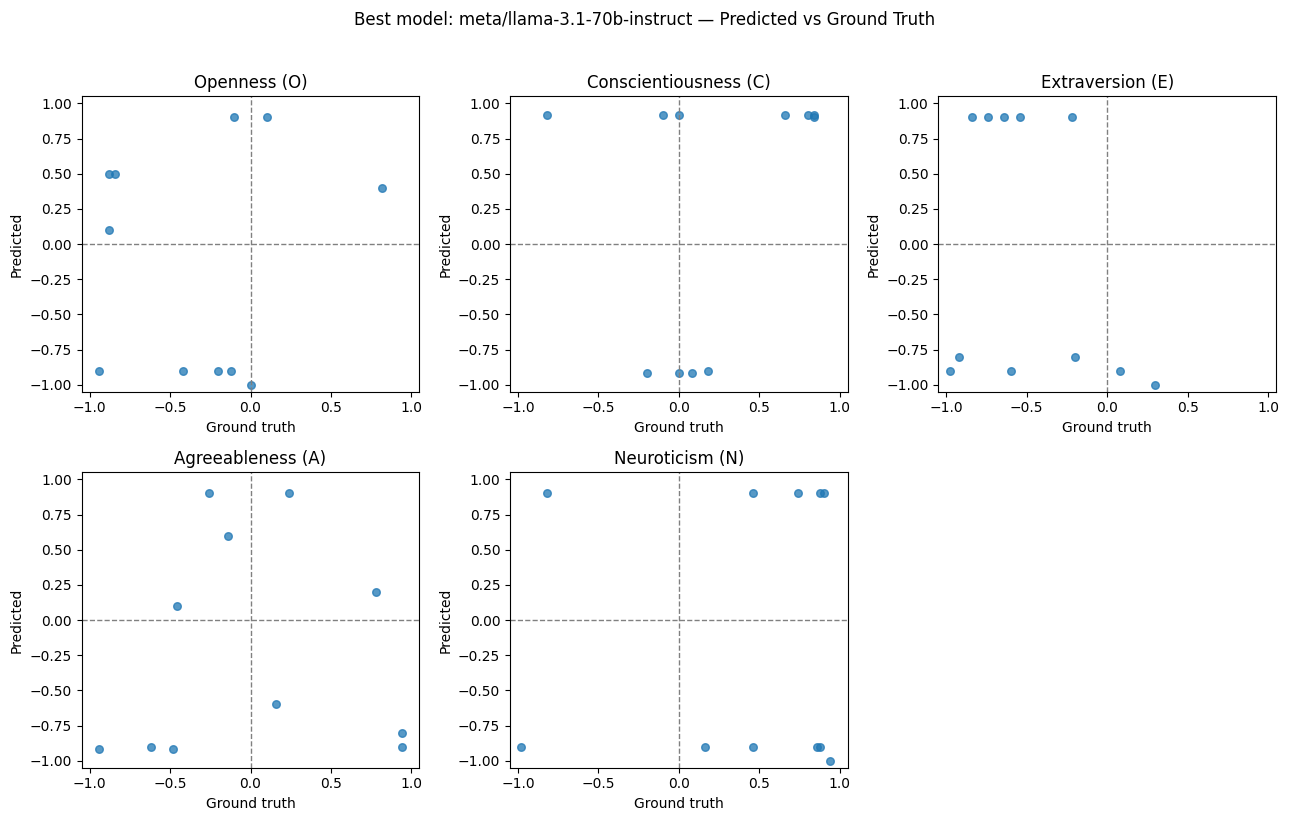

In [ ]:
# Scatter plots for best model: predicted vs ground truth
if best_model is not None:
    d = df[(df["model"] == best_model) & (df["has_pred"])].copy()
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes = axes.flatten()

    for i, t in enumerate(TRAITS):
        ax = axes[i]
        x = d[f"gt_{t}"]
        y = d[f"pred_{t}"]
        ax.scatter(x, y, alpha=0.75, s=30)
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.axvline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(f"{LABELS[t]} ({t})")
        ax.set_xlabel("Ground truth")
        ax.set_ylabel("Predicted")

    axes[-1].axis("off")
    plt.suptitle(f"Best model: {best_model} — Predicted vs Ground Truth", y=1.02)
    plt.tight_layout()
    plt.show()

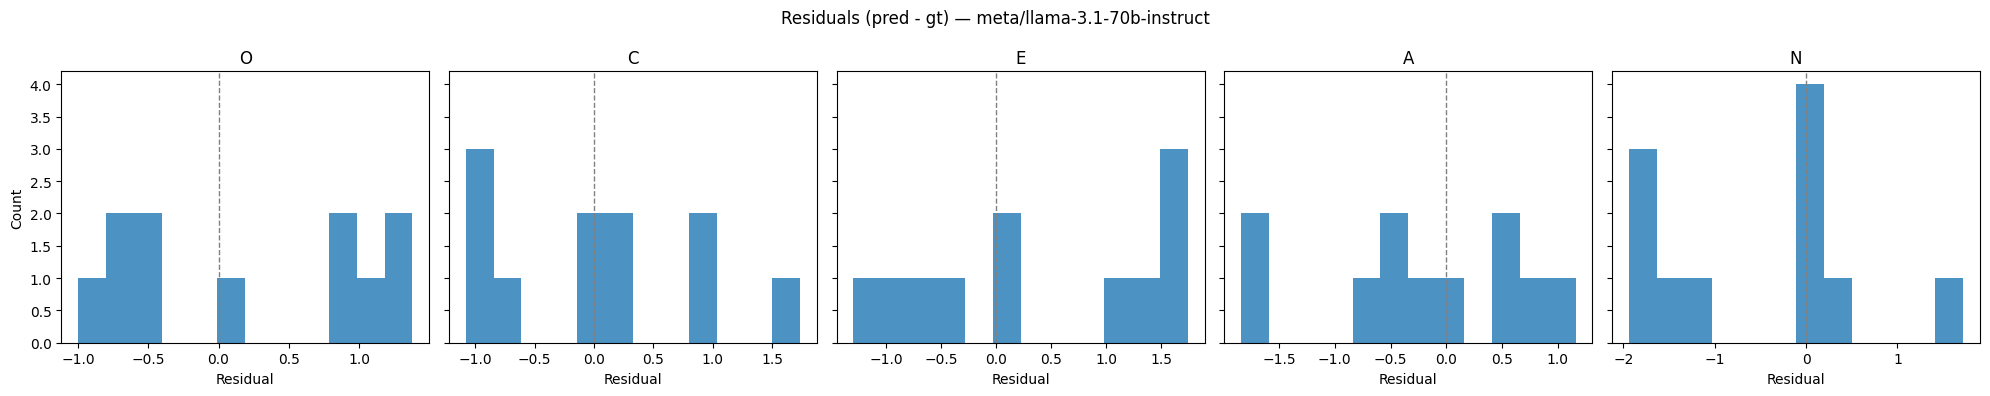

In [ ]:
# Residual distributions (pred - gt) for best model
if best_model is not None:
    d = df[(df["model"] == best_model) & (df["has_pred"])].copy()
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
    for i, t in enumerate(TRAITS):
        res = d[f"pred_{t}"] - d[f"gt_{t}"]
        axes[i].hist(res, bins=12, alpha=0.8)
        axes[i].axvline(0, color="gray", linestyle="--", linewidth=1)
        axes[i].set_title(t)
        axes[i].set_xlabel("Residual")
    axes[0].set_ylabel("Count")
    plt.suptitle(f"Residuals (pred - gt) — {best_model}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Save summary tables (merged across all JSONL when MERGE_ALL_OFFLINE_RUNS is True)
suffix = "_merged" if MERGE_ALL_OFFLINE_RUNS else "_latest"
out_summary = RESULTS_DIR / f"offline_detection_summary{suffix}.csv"
out_trait = RESULTS_DIR / f"offline_detection_trait_metrics{suffix}.csv"
summary_df.to_csv(out_summary, index=False)
trait_df.to_csv(out_trait, index=False)
# Also write legacy names for downstream tools expecting *_latest.csv
summary_df.to_csv(RESULTS_DIR / "offline_detection_summary_latest.csv", index=False)
trait_df.to_csv(RESULTS_DIR / "offline_detection_trait_metrics_latest.csv", index=False)
print("Saved:", out_summary)
print("Saved:", out_trait)
print("Also:", RESULTS_DIR / "offline_detection_summary_latest.csv")

Saved: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results/offline_detection_summary_latest.csv
Saved: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/offline_nv_detection/results/offline_detection_trait_metrics_latest.csv


In [ ]:
# Coverage-aware ranking (quality + reliability)
rank_df = summary_df.copy()
rank_df["coverage"] = rank_df["n"] / float(df["sample_id"].nunique())
rank_df["quality_score"] = rank_df["macro_pearson"]
rank_df["reliability_score"] = rank_df["coverage"]
rank_df["composite_score"] = 0.7 * rank_df["quality_score"] + 0.3 * rank_df["reliability_score"]
rank_df = rank_df.sort_values(["composite_score", "macro_pearson"], ascending=False)

display(rank_df[["model", "n", "coverage", "macro_pearson", "macro_spearman", "macro_mae", "composite_score"]])

,model,n,coverage,macro_pearson,macro_spearman,macro_mae,composite_score
1,meta/llama-3.1-70b-instruct,11,1.000000,0.035867,0.052737,0.850364,0.325107
3,moonshotai/kimi-k2-instruct,11,1.000000,-0.071191,-0.043113,0.806182,0.250166
2,meta/llama-3.3-70b-instruct,11,1.000000,-0.085991,-0.030491,0.700000,0.239806
0,google/gemma-3-12b-it,10,0.909091,-0.060676,-0.014143,0.761733,0.230254


In [ ]:
# Variant-level validity diagnostics (which prompt variant fails most)
variant_rows = []
with open(RESULTS_FILE, "r", encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        model = r.get("model")
        details = r.get("variant_details") or []
        for d in details:
            variant_rows.append({
                "model": model,
                "variant": d.get("variant"),
                "valid_json": d.get("ocean") is not None,
                "has_error": d.get("error") is not None,
                "error": (d.get("error") or "")[:160],
            })

vdf = pd.DataFrame(variant_rows)
if len(vdf):
    validity = (
        vdf.groupby(["model", "variant"]) ["valid_json"]
        .mean()
        .rename("valid_rate")
        .reset_index()
        .sort_values(["model", "valid_rate"], ascending=[True, False])
    )
    display(validity)
else:
    print("No variant_details found in results.")

No variant_details found in results.


In [ ]:
# Failure reason analysis (rate limits / missing model routes / parse failures)
if len(vdf):
    fail_df = vdf[vdf["valid_json"] == False].copy()
    if len(fail_df):
        def simplify(err: str) -> str:
            e = err.lower()
            if "429" in e:
                return "429 rate_limit"
            if "404" in e:
                return "404 model_not_found"
            if "401" in e or "403" in e:
                return "auth_error"
            if "timeout" in e:
                return "timeout"
            if e.strip() == "":
                return "invalid_json_no_error"
            return "other_error"

        fail_df["error_class"] = fail_df["error"].map(simplify)
        fail_summary = (
            fail_df.groupby(["model", "error_class"]).size().rename("count").reset_index()
            .sort_values(["model", "count"], ascending=[True, False])
        )
        display(fail_summary)
    else:
        print("No failures in variant-level outputs.")

In [ ]:
# Auto-interpretation block (human-readable recommendation)
if len(rank_df):
    top = rank_df.iloc[0]
    model = top["model"]
    cov = float(top["coverage"])
    r = float(top["macro_pearson"])
    mae = float(top["macro_mae"])

    if cov < 0.7:
        reliability_note = "Coverage is low; ranking may be biased by API failures."
    elif cov < 0.95:
        reliability_note = "Coverage is moderate; compare again with lower concurrency to reduce 429 errors."
    else:
        reliability_note = "Coverage is high; ranking is relatively stable."

    if r >= 0.2:
        quality_note = "Correlation is promising for this benchmark setup."
    elif r >= 0.05:
        quality_note = "Correlation is weak-to-moderate; prompt/model tuning is still needed."
    else:
        quality_note = "Correlation is weak; detector behavior is not well aligned with PANDORA labels yet."

    print("Recommended current model:", model)
    print(f"- Coverage: {cov:.2%}")
    print(f"- Macro Pearson: {r:.4f}")
    print(f"- Macro MAE: {mae:.4f}")
    print("- Reliability:", reliability_note)
    print("- Quality:", quality_note)
    print("\nAction:")
    print("1) rerun with --max-workers 1-2 to reduce 429, 2) use 100+ samples, 3) compare per-variant valid_rate.")

Recommended current model: meta/llama-3.1-70b-instruct
- Coverage: 100.00%
- Macro Pearson: 0.0359
- Macro MAE: 0.8504
- Reliability: Coverage is high; ranking is relatively stable.
- Quality: Correlation is weak; detector behavior is not well aligned with PANDORA labels yet.

Action:
1) rerun with --max-workers 1-2 to reduce 429, 2) use 100+ samples, 3) compare per-variant valid_rate.


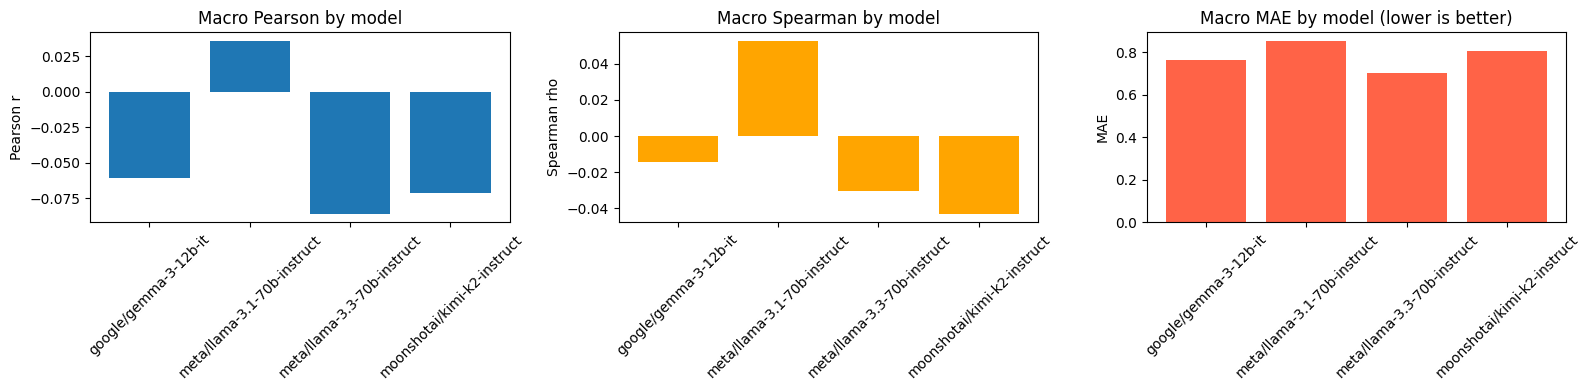

In [ ]:
# Cross-model comparison: macro metrics bars
plot_df = summary_df.copy().sort_values("model")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(plot_df["model"], plot_df["macro_pearson"])
axes[0].set_title("Macro Pearson by model")
axes[0].set_ylabel("Pearson r")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(plot_df["model"], plot_df["macro_spearman"], color="orange")
axes[1].set_title("Macro Spearman by model")
axes[1].set_ylabel("Spearman rho")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(plot_df["model"], plot_df["macro_mae"], color="tomato")
axes[2].set_title("Macro MAE by model (lower is better)")
axes[2].set_ylabel("MAE")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

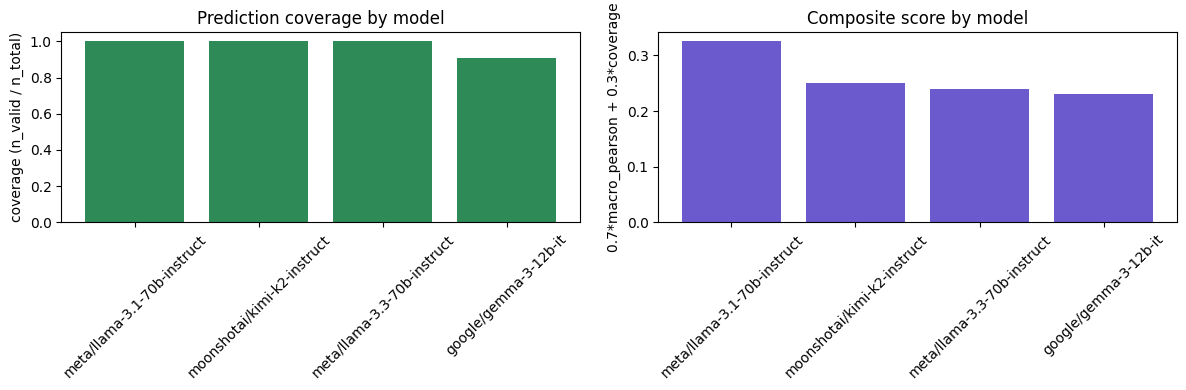

In [ ]:
# Cross-model comparison: coverage + composite score
if "rank_df" in globals() and len(rank_df):
    p2 = rank_df.sort_values("composite_score", ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(p2["model"], p2["coverage"], color="seagreen")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title("Prediction coverage by model")
    axes[0].set_ylabel("coverage (n_valid / n_total)")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(p2["model"], p2["composite_score"], color="slateblue")
    axes[1].set_title("Composite score by model")
    axes[1].set_ylabel("0.7*macro_pearson + 0.3*coverage")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("Run ranking cell first (coverage-aware ranking).")

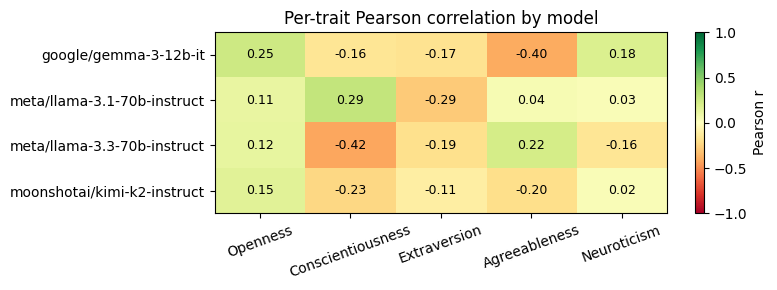

In [ ]:
# Heatmap-like matrix: per-trait Pearson by model
if len(trait_df):
    pivot = trait_df.pivot(index="model", columns="trait", values="pearson")
    pivot = pivot[["O", "C", "E", "A", "N"]]

    fig, ax = plt.subplots(figsize=(8, max(3, 0.6 * len(pivot))))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([LABELS[t] for t in pivot.columns], rotation=20)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Per-trait Pearson correlation by model")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            txt = "nan" if pd.isna(val) else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center", color="black", fontsize=9)

    plt.colorbar(im, ax=ax, label="Pearson r")
    plt.tight_layout()
    plt.show()

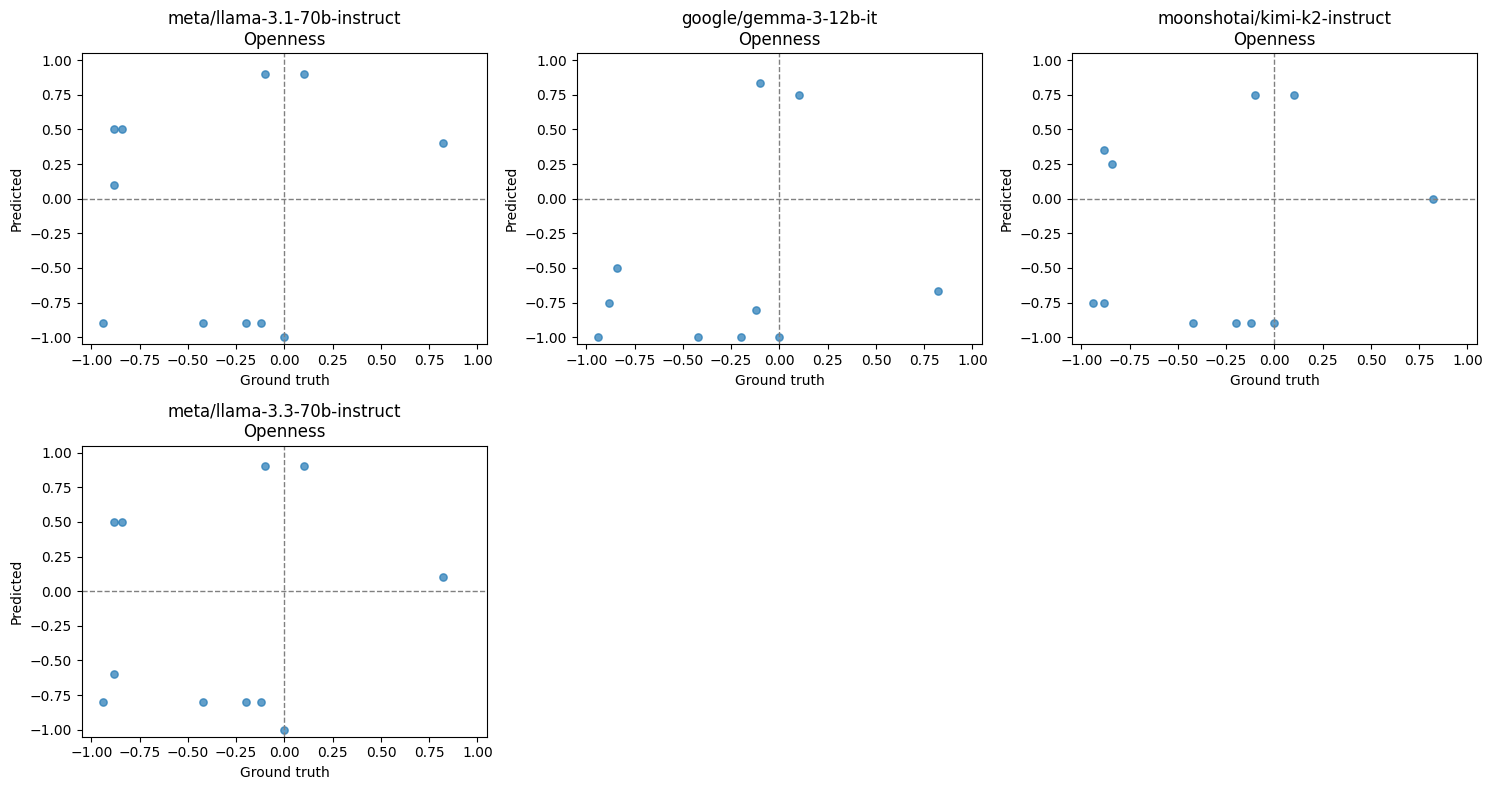

In [ ]:
# Multi-model scatter for a selected trait
selected_trait = "O"  # change to C/E/A/N
valid_models = summary_df[summary_df["n"] > 0]["model"].tolist()
if valid_models:
    n_models = len(valid_models)
    cols = 3
    rows_n = int(np.ceil(n_models / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(5 * cols, 4 * rows_n), squeeze=False)
    axes = axes.flatten()

    for i, model in enumerate(valid_models):
        ax = axes[i]
        d = df[(df["model"] == model) & (df["has_pred"])].copy()
        x = d[f"gt_{selected_trait}"]
        y = d[f"pred_{selected_trait}"]
        ax.scatter(x, y, alpha=0.7, s=28)
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.axvline(0, color="gray", linestyle="--", linewidth=1)
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(f"{model}\n{LABELS[selected_trait]}")
        ax.set_xlabel("Ground truth")
        ax.set_ylabel("Predicted")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No valid model predictions to plot.")